# Preparation for interpolation

In [1]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Preparation interpolation

search F range 

In [2]:
sigma_rsl=5000
# sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
sigmas=np.linspace(0.1, 59.0, sigma_rsl)
print([np.min(sigmas),np.max(sigmas)])
C0s=np.zeros_like(sigmas)
As=np.zeros_like(sigmas)
Vars_sqrt=np.zeros_like(sigmas)
for i, sigma in enumerate(sigmas):
    C0=C0_sigma(sigma)
    C0s[i]=C0
    A=find_A_sigma(C_0=C0, sigma=sigma)
    As[i]=A
    Vars_sqrt[i]=np.sqrt(calculate_var(C0=C0, A=A, sigma_DM=sigma))

[0.1, 59.0]


/mnt/d/Document/Research/FRB/cosmology/FRB_cosmology/code/../Python_scripts/cosmo_support.py:625: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  second_moment, _ = quad(second_moment_integrand, x_min, x_max,limit=limit)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


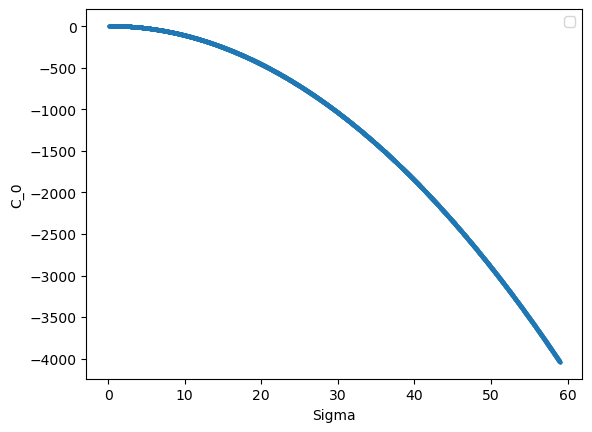

In [3]:
plt.scatter(sigmas, C0s,  s=3)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


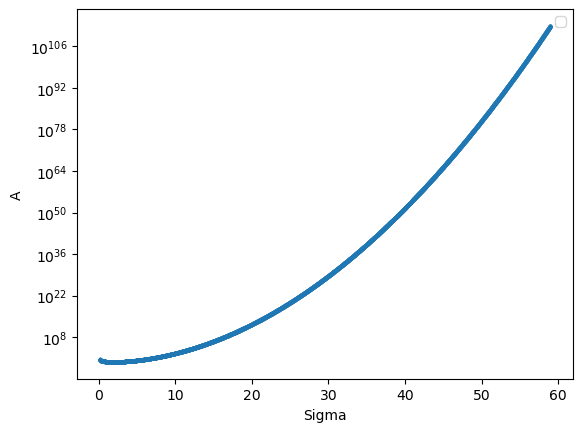

In [4]:
plt.scatter(sigmas, As,  s=3)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
plt.legend()

plt.show()

Text(0.5, 0, 'Variance_sqrt')

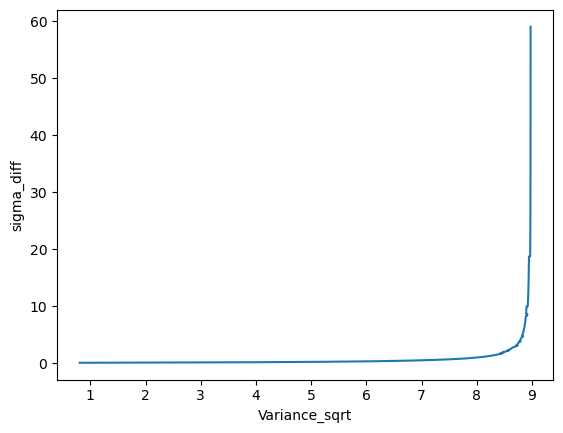

In [5]:
plt.plot(Vars_sqrt, sigmas)
plt.ylabel('sigma_diff')
plt.xlabel('Variance_sqrt')
# plt.xscale('log')
# plt.yscale('log')

In [6]:
# interpolation example

# C0_sigma = interpolate.interp1d(sigmas, C0s, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# A_sigma = interpolate.interp1d(sigmas, As, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

# sigma_var = interpolate.interp1d(Vars_sqrt, sigmas, kind=1,bounds_error=False, 
#     # fill_value='extrapolate'
#     )

In [8]:
np.save('./interpolation/sigmas.npy', sigmas)
np.save('./interpolation/As.npy', As)
np.save('./interpolation/C0s.npy', C0s)
np.save('./interpolation/Vars_sqrt.npy', Vars_sqrt)